In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Estimation par Maximum de Vraisemblance (MLE)

On observe $n$ échantillons indépendants issus d'une loi gaussienne :

$$x_i \sim \mathcal{N}(\mu, \sigma^2), \quad i = 1, \dots, n$$

- $\sigma^2$ est **inconnu**
- $\mu$ est **inconnu** — ce sont les paramètres à estimer

In [2]:
true_sigma = 3 # unknown var
true_mu = -1.8 # # unknown var, for the exercice
x = np.random.normal(true_mu, true_sigma, size=50) # initial data

Ci-dessous l'histogramme des données simulées ($n=50$, $\mu=-1.8$, $\sigma=3$).

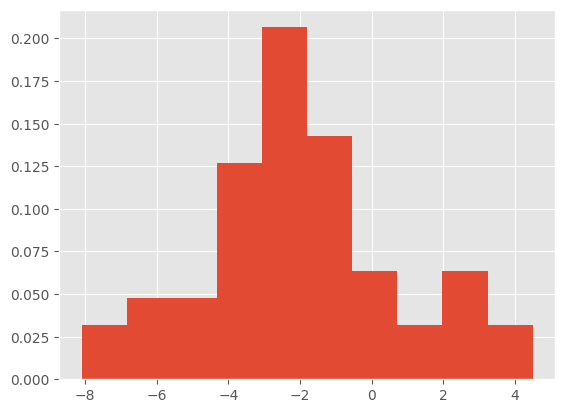

In [3]:
plt.hist(x, density=True);

## Densité de probabilité gaussienne

$$p(x \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$


In [4]:
p = lambda x, mu, sigma: 1/np.sqrt(2*np.pi*sigma) * np.exp(-np.square(x-mu)/(2*np.square(sigma)))
log_p = lambda x, mu, sigma: -0.5 * np.log(2 * np.pi * sigma**2) - (x - mu)**2 / (2 * sigma**2)

## Fonction de vraisemblance

Pour $n$ observations indépendantes, la vraisemblance est :

$$L(\mu, \sigma) = \prod_{i=1}^{n} p(x_i \mid \mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

**On veut maximisé la vraisemblance**

### Log-vraisemblance

On prend le logarithme pour convertir le produit en somme (plus stable numériquement) :

$$\ell(\mu, \sigma) = \log L(\mu, \sigma) = \sum_{i=1}^{n} \log p(x_i \mid \mu)$$

$$= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i - \mu)^2$$

In [5]:
n_points = 100
Mu_grid = np.linspace(-5, 3, n_points)
Sigma_grid = np.linspace(0.2, 6, n_points)

def likelihood(Mu_grid, Sigma_grid, x=x):
    L = np.zeros((len(Mu_grid), len(Sigma_grid)))
    for i, mu in enumerate(Mu_grid):
        for j, sigma in enumerate(Sigma_grid):
            # Sommer les log au lieu de multiplier (stabilité numérique)
            log_l = sum(log_p(xi, mu, sigma) for xi in x)
            L[i, j] = log_l
    return L

def likelihood_vectorized(Mu_grid, Sigma_grid, x=x):
    # Reshape pour le broadcasting
    x_   = np.asarray(x).reshape(1, 1, -1)       # (1, 1, n)
    mu_  = np.asarray(Mu_grid).reshape(-1, 1, 1)  # (M, 1, 1)
    sig_ = np.asarray(Sigma_grid).reshape(1, -1, 1)  # (1, S, 1)

    # log p(xi | mu, sigma) pour tous les (mu, sigma, xi) → (M, S, n)
    L = log_p(x_, mu_, sig_)  # (M, S, n)
    return L.sum(axis=-1)  # somme sur xi → (M, S)

## Calcul de l'estimateur MLE

### Varaible $\mu$
On maximise $\ell(\mu)$ en dérivant par rapport à $\mu$ et en égalisant à zéro :

$$\frac{d\ell}{d\mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0$$

$$\sum_{i=1}^{n} x_i - n\hat{\mu} = 0$$

$$\boxed{\hat{\mu}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n} x_i = \bar{x}}$$

Le MLE de la moyenne d'une gaussienne est simplement la **moyenne empirique**.

### Variable $\sigma$

On pose $v = \sigma^2$ pour simplifier la dérivation :

$$\ell(v) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(v) - \frac{1}{2v}\sum_{i=1}^{n}(x_i - \hat{\mu})^2$$

On dérive par rapport à $v$ et on égalise à zéro :

$$\frac{d\ell}{dv} = -\frac{n}{2v} + \frac{1}{2v^2}\sum_{i=1}^{n}(x_i - \hat{\mu})^2 = 0$$

On multiplie par $2v^2$ :

$$-nv + \sum_{i=1}^{n}(x_i - \hat{\mu})^2 = 0$$

$$\boxed{\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{\mu})^2}$$

> **Note :** c'est un estimateur **biaisé** — il divise par $n$ et non $n-1$. L'estimateur sans biais (variance de Bessel) divise par $n-1$, mais ce n'est pas le MLE.

In [6]:
likelihood_values = likelihood_vectorized(Mu_grid, Sigma_grid, x)
flat_idx = likelihood_values.argmax() 
mu_idx = flat_idx // likelihood_values.shape[1]
sigma_idx = flat_idx % likelihood_values.shape[1]

dMu = np.sum(x)/len(x) # Solution analytique pour ce problème, à vérifier avec la courbe de likelihood
mu_num = Mu_grid[mu_idx] # Solution numérique : trouver le max de la courbe de likelihood

dSigma = np.sqrt(np.sum((x-dMu)**2)/len(x)) # Solution analytique pour ce problème, à vérifier avec la courbe de likelihood
sigma_num = Sigma_grid[sigma_idx] # Solution numérique : trouver le max de la courbe de likelihood

In [7]:
print("mu: {}, \nmu_num: {}".format(dMu, mu_num))
print("sigma: {}, \nsigma_num: {}".format(dSigma, sigma_num))

mu: -2.0342578936917106, 
mu_num: -2.01010101010101
sigma: 2.7064394385783896, 
sigma_num: 2.7191919191919194


In [8]:
from scipy.stats import norm
mu_hat, sigma_hat = norm.fit(x)  # MLE directement
print("mu_hat: {}, \nsigma_hat: {}".format(mu_hat, sigma_hat)) # same as dMu & dSigma

mu_hat: -2.0342578936917106, 
sigma_hat: 2.7064394385783896


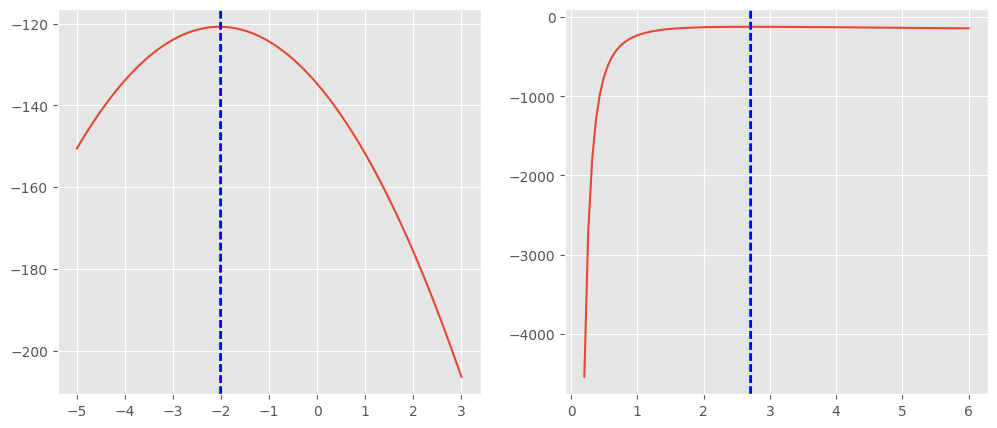

In [9]:
mu_likelihood = likelihood_values[:, sigma_idx] # Fixer sigma pour visualiser l'effet de mu
sigma_likelihood = likelihood_values[mu_idx, :] # Fixer mu pour visualiser l'effet de sigma 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(Mu_grid, mu_likelihood)
ax1.axvline(dMu, ls="--", color="green")
ax1.axvline(mu_num, ls="--", color="blue")
ax2.plot(Sigma_grid, sigma_likelihood)
ax2.axvline(dSigma, ls="--", color="green")
ax2.axvline(sigma_num, ls="--", color="blue")

In [10]:
L_true = likelihood([dMu], [dSigma], x)
L_true

array([[-120.7286222]])

## Visualisation : histogramme vs densité estimée

On superpose l'histogramme normalisé (`density=True`) des données avec la densité $p(x \mid \hat{\mu}, \hat{\sigma})$ :

- L'histogramme est normalisé de sorte que l'**aire totale = 1**
- La courbe $p$ est la densité gaussienne évaluée au MLE $\hat{\mu} = \bar{x}$

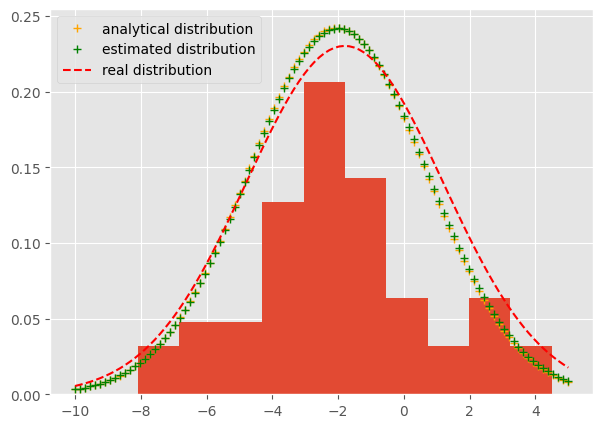

In [11]:
plt.figure(figsize=(7, 5))
plt.hist(x, density=True)
idx = np.linspace(-10,5,100)
plt.plot(idx, p(idx, dMu, dSigma), "+", label="analytical distribution", color="orange")
plt.plot(idx, p(idx, mu_num, sigma_num), "+", label="estimated distribution", color="green")
plt.plot(idx, p(idx, true_mu, true_sigma), "--", label="real distribution", color="red")
plt.legend()

the MLE recipe

1. Write down the likelihood L(θ) = ∏ p(xᵢ | θ)
1. Take the log: ℓ(θ) = Σ log p(xᵢ | θ)
1. We want to maximise likelihood:
    1. Differentiate with respect to θ and set to zero: dℓ/dθ = 0<br>
    Solve for θ — that's your MLE θ̂
    1. Identifie the max likelihood calculated from the data, take argmax, find MLE θ̂

---

# MLE pour la loi de Bernoulli — Jeu de pile ou face

On observe $n$ lancers d'une pièce. Chaque lancer est modélisé par une variable de Bernoulli :

$$x_i \in \{0, 1\}, \quad i = 1, \dots, n$$

- $x_i = 1$ : pile (succès)
- $x_i = 0$ : face (échec)
- $p$ : probabilité de pile — **inconnu**, c'est le paramètre à estimer

Nombre de piles : 70 / 100


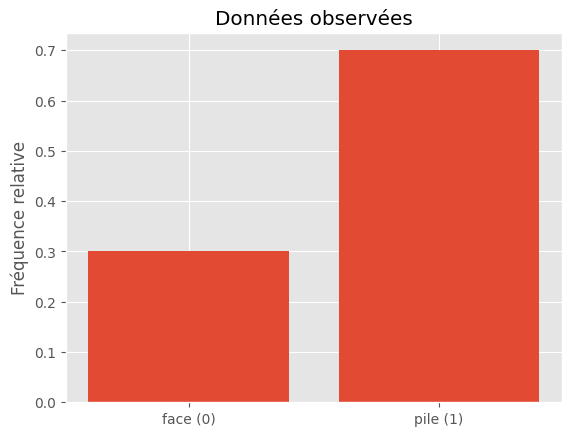

In [12]:
true_theta = 0.7  # probabilité inconnue (à estimer)
n = 100
x_bern = np.random.binomial(1, true_theta, size=n)
print(f"Nombre de piles : {x_bern.sum()} / {n}")
plt.bar([0, 1], [(x_bern == 0).mean(), (x_bern == 1).mean()])
plt.xticks([0, 1], ['face (0)', 'pile (1)'])
plt.ylabel('Fréquence relative')
plt.title('Données observées');

## Masse de probabilité (PMF)

La probabilité d'observer $x_i$ sachant $\theta$ est :

$$p(x_i \mid \theta) = \theta^{x_i}(1-\theta)^{1-x_i}$$

- Si $x_i = 1$ : $p = \theta$
- Si $x_i = 0$ : $p = 1 - \theta$

In [13]:
p_bern = lambda x, theta: theta**x * (1-theta)**(1-x)

## Log-vraisemblance

Pour $n$ observations indépendantes :

$$L(\theta) = \prod_{i=1}^{n} p(x_i \mid \theta) = \prod_{i=1}^{n} \theta^{x_i}(1-\theta)^{1-x_i}$$

On passe au log :

$$\ell(\theta) = \sum_{i=1}^{n} \left[ x_i \log \theta + (1 - x_i)\log(1-\theta) \right]$$

En posant $k = \sum x_i$ (nombre de piles) :

$$\ell(\theta) = k\log \theta + (n - k)\log(1-\theta)$$

In [14]:
Theta_grid = np.linspace(0.01, 0.99, 100)

log_bern = lambda x, theta: x * np.log(theta) + (1-x) * np.log(1-theta)

def log_likelihood_bern(Theta_grid, x=x_bern):
    return [sum(log_bern(xi, theta) for xi in x) for theta in Theta_grid]

def log_likelihood_bern_vectorized(Theta_grid, x=x_bern):
    x_ = np.asarray(x).reshape(1, -1)  # (1, n)
    theta_ = np.asarray(Theta_grid).reshape(-1, 1)  # (T, 1)
    L = log_bern(x_, theta_)  # (T, n)
    return L.sum(axis=1)  # somme sur les données → (T,)

lik_bern = log_likelihood_bern_vectorized(Theta_grid)

## Calcul de l'estimateur MLE

On dérive $\ell(\theta)$ et on égalise à zéro :

$$\frac{d\ell}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta} = 0$$

On multiplie par $\theta(1-\theta)$ :

$$k(1-\theta) - (n-k)\theta = 0$$

$$k - k\theta - n\theta + k\theta = 0$$

$$k = n\theta$$

$$\boxed{\hat{\theta}_{\text{MLE}} = \frac{k}{n} = \frac{1}{n}\sum_{i=1}^{n} x_i}$$

Le MLE est simplement la **fréquence observée** de succès.

theta_hat (analytique) = 0.700
theta_num (numérique)  = 0.703
true_theta             = 0.7


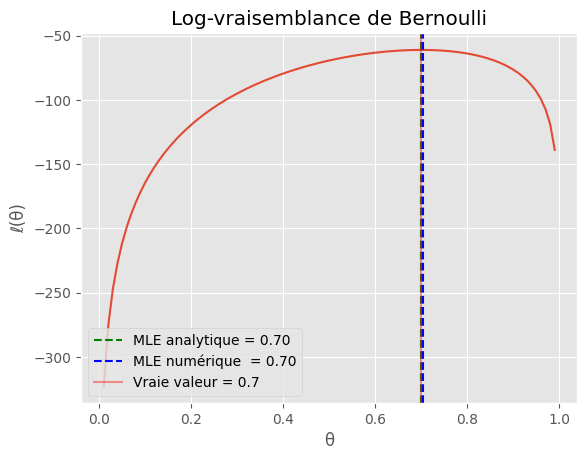

In [15]:
theta_hat = x_bern.mean()  # MLE analytique
theta_num = Theta_grid[np.argmax(lik_bern)]  # MLE numérique
print(f"theta_hat (analytique) = {theta_hat:.3f}")
print(f"theta_num (numérique)  = {theta_num:.3f}")
print(f"true_theta             = {true_theta}")

plt.plot(Theta_grid, lik_bern)
plt.axvline(theta_hat, ls='--', color='green', label=f'MLE analytique = {theta_hat:.2f}')
plt.axvline(theta_num, ls='--', color='blue',  label=f'MLE numérique  = {theta_num:.2f}')
plt.axvline(true_theta, ls='-', color='red', alpha=0.4, label=f'Vraie valeur = {true_theta}')
plt.xlabel('θ')
plt.ylabel('ℓ(θ)')
plt.title('Log-vraisemblance de Bernoulli')
plt.legend();